# Model Inference & Scenario Testing — E-Waste Asset Lifecycle Optimizer

Loads the trained `risk_label` classifier and tests it across:
1. **Held-out test set** — reproducible 15% split from the fixed dataset, full metrics
2. **Hand-crafted scenarios** — 10 realistic edge cases covering every lifecycle zone
3. **Borderline / stress cases** — inputs right on decision boundaries
4. **Partial telemetry** — low `data_completeness` records (policy-only path)

Artifacts loaded from `models/`:
- `risk_label_model.joblib` — sklearn `Pipeline` (preprocessor + classifier) + `LabelEncoder`
- `model_metadata.json` — feature lists, thresholds, training metrics

## 1. Import Required Libraries

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["axes.titlesize"]  = 12
plt.rcParams["axes.titleweight"] = "bold"

# ── Paths ─────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(".")          # notebooks run from their own directory
MODEL_PATH   = NOTEBOOK_DIR / "models" / "risk_label_model.joblib"
META_PATH    = NOTEBOOK_DIR / "models" / "model_metadata.json"
DATA_PATH    = NOTEBOOK_DIR / "training_data_phase5_1235records_fixed.csv"

print("✓ Libraries loaded")

✓ Libraries loaded


## 2. Load Model, Metadata & Test Data

In [2]:
# ── Load model artifact ───────────────────────────────────────────────────────
artifact = joblib.load(MODEL_PATH)
pipeline = artifact["pipeline"]
le       = artifact["label_encoder"]

# ── Load metadata ─────────────────────────────────────────────────────────────
with open(META_PATH) as f:
    meta = json.load(f)

NUM_FEATS = meta["numeric_features"]
CAT_FEATS = meta["categorical_features"]
ALL_FEATS = CAT_FEATS + NUM_FEATS
CLASSES   = le.classes_          # ['high', 'low', 'medium']

print(f"✓ Model loaded   : {meta['best_model']}")
print(f"  Trained at     : {meta['trained_at']}")
print(f"  Data source    : {meta['data_source']}")
print(f"  Train records  : {meta['n_train']:,}  |  Test records: {meta['n_test']:,}")
print(f"  Saved metrics  → test accuracy {meta['metrics']['test']['accuracy']:.4f}  "
      f"AUC-ROC {meta['metrics']['test']['auc_roc_macro_ovr']:.4f}")
print(f"\n  Classes: {list(CLASSES)}")

# ── Reproduce the same 15% test split used during training ────────────────────
RANDOM_SEED = 42
EXCLUDE = {"risk_label", "risk_score", "asset_id", "purchase_date", "created_at",
           "purchase_year", "age_in_months_recalc"}

df = pd.read_csv(DATA_PATH, parse_dates=["purchase_date", "created_at"])
X  = df[[c for c in ALL_FEATS if c in df.columns]].copy()
for col in CAT_FEATS:
    if col in X.columns:
        X[col] = X[col].astype(str)
y = le.transform(df["risk_label"])

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_SEED, stratify=y
)
print(f"\n✓ Test split reproduced: {len(X_test):,} records")

✓ Model loaded   : Logistic Regression (baseline)
  Trained at     : 2026-02-28T19:37:50.397297
  Data source    : training_data_phase5_1235records_fixed.csv
  Train records  : 1,049  |  Test records: 186
  Saved metrics  → test accuracy 0.9462  AUC-ROC 0.9962

  Classes: ['high', 'low', 'medium']

✓ Test split reproduced: 186 records


## 3. Held-Out Test Set Evaluation

Run the loaded model against the reproduced 15% test split and confirm metrics match what was saved during training.

Test accuracy : 0.9462  (saved: 0.9462)
Test AUC-ROC  : 0.9962  (saved: 0.9962)

Classification report:
              precision    recall  f1-score   support

        high       0.94      0.97      0.96        69
         low       0.98      0.93      0.95        43
      medium       0.93      0.93      0.93        74

    accuracy                           0.95       186
   macro avg       0.95      0.94      0.95       186
weighted avg       0.95      0.95      0.95       186

✓ Accuracy matches saved  : True
✓ AUC-ROC matches saved   : True


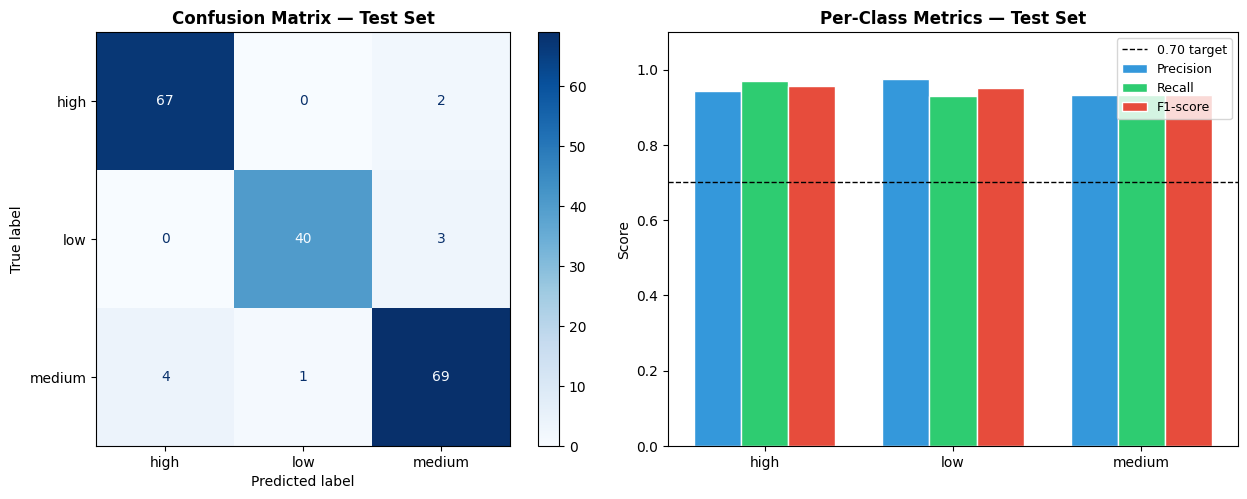

In [3]:
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)

acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
rep  = classification_report(y_test, y_pred, target_names=CLASSES, output_dict=True)

print(f"Test accuracy : {acc:.4f}  (saved: {meta['metrics']['test']['accuracy']})")
print(f"Test AUC-ROC  : {auc:.4f}  (saved: {meta['metrics']['test']['auc_roc_macro_ovr']})")
print(f"\nClassification report:")
print(classification_report(y_test, y_pred, target_names=CLASSES))

# Sanity check — reproduced metrics should match saved ones
tol = 0.001
acc_match = abs(acc - meta["metrics"]["test"]["accuracy"]) < tol
auc_match = abs(auc - meta["metrics"]["test"]["auc_roc_macro_ovr"]) < tol
print(f"✓ Accuracy matches saved  : {acc_match}")
print(f"✓ AUC-ROC matches saved   : {auc_match}")

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=CLASSES, cmap="Blues", ax=axes[0]
)
axes[0].set_title("Confusion Matrix — Test Set")

# Per-class F1, Precision, Recall
metrics_data = {
    cls: [rep[cls]["precision"], rep[cls]["recall"], rep[cls]["f1-score"]]
    for cls in CLASSES
}
x   = np.arange(len(CLASSES))
w   = 0.25
clr = ["#3498db", "#2ecc71", "#e74c3c"]
for i, (metric_name, c) in enumerate(zip(["Precision", "Recall", "F1-score"], clr)):
    vals = [metrics_data[cls][i] for cls in CLASSES]
    axes[1].bar(x + i * w, vals, w, label=metric_name, color=c, edgecolor="white")
axes[1].set_xticks(x + w)
axes[1].set_xticklabels(CLASSES)
axes[1].set_ylim(0, 1.1)
axes[1].set_title("Per-Class Metrics — Test Set")
axes[1].set_ylabel("Score")
axes[1].axhline(0.70, color="black", linestyle="--", linewidth=1, label="0.70 target")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. Define Hand-Crafted Test Scenarios

Ten scenarios covering every lifecycle zone and edge condition:

| # | Name | Expected zone | Expected label |
|---|------|---------------|----------------|
| 1 | Brand-new healthy laptop | REDEPLOY (<0.3) | low |
| 2 | Young asset, minor issues | RESALE (0.3–0.5) | medium / low |
| 3 | Mid-life, average wear | REFURBISH (0.5–0.7) | medium |
| 4 | Overheating server, aging | REPAIR (0.7–0.8) | high |
| 5 | End-of-life, all signals maxed | RECYCLE (≥0.8) | high |
| 6 | Borderline medium→high | Near 0.55 threshold | medium / high |
| 7 | Borderline low→medium | Near 0.35 threshold | low / medium |
| 8 | Old but well-maintained | RESALE / REDEPLOY | low / medium |
| 9 | Partial telemetry (low completeness) | any | any |
| 10 | High incidents, young age | REPAIR / REFURBISH | high |

In [ ]:
# Helper: derive the computed numeric fields that the model needs
def derive_features(row: dict) -> dict:
    """Auto-derive incident_rate, ratios and degradation from raw values."""
    age   = row.get("age_in_months", 1)
    total = row.get("total_incidents", 0)
    crit  = row.get("critical_incidents", 0)
    bh    = row.get("battery_health_percent", 100)
    therm = row.get("thermal_events_count", 0)
    row["incident_rate_per_month"]    = round(total / max(age / 30 * 3, 1), 3)
    row["critical_incident_ratio"]    = round(crit / total, 4) if total > 0 else 0.0
    row["battery_degradation_rate"]   = round((100 - bh) / age, 4) if age > 0 else 0.0
    row["thermal_events_per_month"]   = round(therm / age, 4) if age > 0 else 0.0
    return row

# ── Risk score calc matches train_model.py formula ────────────────────────────
def calc_risk_score(row: dict) -> float:
    bs = (100 - row["battery_health_percent"]) / 100
    ts = min(row["thermal_events_count"] / 50.0, 1.0)
    ds = min(row["smart_sectors_reallocated"] / 100.0, 1.0)
    ins = min(row["total_incidents"] / 20.0, 1.0)
    ag = min(row["age_in_months"] / 72.0, 1.0)
    return round(bs*0.25 + ts*0.20 + ds*0.20 + ins*0.20 + ag*0.15, 3)

def risk_zone(score: float, age: int) -> str:
    if score >= 0.80 and age >= 42: return "RECYCLE"
    if score >= 0.70:               return "REPAIR"
    if score >= 0.50:               return "REFURBISH"
    if score < 0.30:                return "REDEPLOY"
    return "RESALE"

# ── Default values shared across scenarios ────────────────────────────────────
DEFAULTS = dict(
    device_type="Laptop", brand="Dell", department="Engineering",
    region="North America", usage_type="Standard", os="Windows 11",
    overheating_issues="False", battery_cycles=100,
    daily_usage_hours=8.0, avg_resolution_time_hours=24.0,
    high_incidents=0, medium_incidents=0, low_incidents=0,
    model_year=2024, data_completeness=1.0,
)

scenarios_raw = [
    # 1 Brand-new healthy laptop
    dict(name="Brand-new healthy laptop",
         age_in_months=6, battery_health_percent=98, battery_cycles=40,
         thermal_events_count=0, smart_sectors_reallocated=0,
         total_incidents=0, critical_incidents=0,
         performance_rating=5, overheating_issues="False",
         model_year=2026, data_completeness=1.0),

    # 2 Young asset, minor wear
    dict(name="Young asset, minor wear",
         age_in_months=18, battery_health_percent=88, battery_cycles=180,
         thermal_events_count=2, smart_sectors_reallocated=5,
         total_incidents=3, critical_incidents=0,
         performance_rating=4, overheating_issues="False",
         model_year=2024, data_completeness=1.0),

    # 3 Mid-life average wear
    dict(name="Mid-life, average wear",
         age_in_months=36, battery_health_percent=74, battery_cycles=400,
         thermal_events_count=7, smart_sectors_reallocated=28,
         total_incidents=8, critical_incidents=1,
         performance_rating=3, overheating_issues="False",
         model_year=2023, data_completeness=1.0),

    # 4 Overheating server, aging
    dict(name="Overheating server, aging",
         device_type="Server", os="Linux", brand="HPE",
         age_in_months=50, battery_health_percent=60, battery_cycles=600,
         thermal_events_count=35, smart_sectors_reallocated=60,
         total_incidents=12, critical_incidents=2,
         performance_rating=2, overheating_issues="True",
         model_year=2021, data_completeness=1.0),

    # 5 End-of-life, all signals maxed → RECYCLE
    dict(name="End-of-life, all signals maxed",
         device_type="Desktop", brand="Lenovo",
         age_in_months=72, battery_health_percent=20, battery_cycles=900,
         thermal_events_count=48, smart_sectors_reallocated=95,
         total_incidents=20, critical_incidents=4,
         performance_rating=1, overheating_issues="True",
         model_year=2019, data_completeness=1.0),

    # 6 Borderline medium→high (score ~0.54)
    dict(name="Borderline medium/high (~0.54)",
         age_in_months=40, battery_health_percent=65, battery_cycles=450,
         thermal_events_count=14, smart_sectors_reallocated=35,
         total_incidents=9, critical_incidents=1,
         performance_rating=3, overheating_issues="False",
         model_year=2022, data_completeness=1.0),

    # 7 Borderline low→medium (score ~0.35)
    dict(name="Borderline low/medium (~0.35)",
         age_in_months=20, battery_health_percent=83, battery_cycles=220,
         thermal_events_count=4, smart_sectors_reallocated=12,
         total_incidents=5, critical_incidents=0,
         performance_rating=4, overheating_issues="False",
         model_year=2024, data_completeness=1.0),

    # 8 Old but well-maintained
    dict(name="Old but well-maintained",
         age_in_months=60, battery_health_percent=85, battery_cycles=700,
         thermal_events_count=3, smart_sectors_reallocated=8,
         total_incidents=4, critical_incidents=0,
         performance_rating=4, overheating_issues="False",
         model_year=2020, data_completeness=1.0),

    # 9 Partial telemetry (low data_completeness)
    dict(name="Partial telemetry (completeness=0.45)",
         age_in_months=30, battery_health_percent=79, battery_cycles=310,
         thermal_events_count=5, smart_sectors_reallocated=18,
         total_incidents=6, critical_incidents=1,
         performance_rating=3, overheating_issues="False",
         model_year=2023, data_completeness=0.45),

    # 10 High incidents, young age
    dict(name="High incidents, young device",
         age_in_months=14, battery_health_percent=90, battery_cycles=150,
         thermal_events_count=12, smart_sectors_reallocated=55,
         total_incidents=15, critical_incidents=3,
         performance_rating=2, overheating_issues="True",
         model_year=2025, data_completeness=1.0),
]

# Fill defaults and derive computed features
scenarios = []
for s in scenarios_raw:
    row = {**DEFAULTS, **s}
    row["high_incidents"]   = row.get("high_incidents",   int(row["total_incidents"] * 0.2))
    row["medium_incidents"] = row.get("medium_incidents", int(row["total_incidents"] * 0.3))
    row["low_incidents"]    = max(row["total_incidents"] - row["critical_incidents"]
                                  - row["high_incidents"] - row["medium_incidents"], 0)
    row = derive_features(row)
    row["risk_score_expected"] = calc_risk_score(row)
    row["zone_expected"]       = risk_zone(row["risk_score_expected"], row["age_in_months"])
    scenarios.append(row)

scenario_names = [s["name"] for s in scenarios]
print(f"✓ {len(scenarios)} scenarios defined")
for s in scenarios:
    print(f"  [{s['zone_expected']:10s}  score={s['risk_score_expected']:.3f}]  {s['name']}")

## 5. Run Predictions on Each Scenario

In [ ]:
def confidence_band(max_proba: float) -> str:
    if max_proba >= 0.90: return "HIGH confidence"
    if max_proba >= 0.70: return "MEDIUM confidence"
    return "LOW confidence"

def lifecycle_action(predicted_label: str, risk_score: float, age: int) -> str:
    zone = risk_zone(risk_score, age)
    actions = {
        "RECYCLE":   "🔴 RECYCLE  — decommission and certify e-waste disposal",
        "REPAIR":    "🟠 REPAIR   — raise maintenance ticket, assess hardware",
        "REFURBISH": "🟡 REFURBISH — clean, upgrade, return to pool",
        "RESALE":    "🟢 RESALE   — sell/lease to secondary market",
        "REDEPLOY":  "🔵 REDEPLOY — reassign to another department",
    }
    return actions.get(zone, "UNKNOWN")

# Build input DataFrame (only model features, in correct order)
feat_cols = CAT_FEATS + NUM_FEATS
scenario_df = pd.DataFrame(scenarios)[feat_cols].copy()
for col in CAT_FEATS:
    scenario_df[col] = scenario_df[col].astype(str)

# Predict
pred_encoded = pipeline.predict(scenario_df)
pred_probas  = pipeline.predict_proba(scenario_df)
pred_labels  = le.inverse_transform(pred_encoded)

# Build results table
rows = []
for i, s in enumerate(scenarios):
    proba_dict = {cls: round(pred_probas[i][j], 4) for j, cls in enumerate(CLASSES)}
    max_p      = max(proba_dict.values())
    pred_lbl   = pred_labels[i]
    exp_zone   = s["zone_expected"]
    exp_score  = s["risk_score_expected"]
    action     = lifecycle_action(pred_lbl, exp_score, s["age_in_months"])
    conf       = confidence_band(max_p)
    
    rows.append({
        "Scenario":         s["name"],
        "Expected Zone":    exp_zone,
        "Exp. risk_score":  exp_score,
        "Predicted Label":  pred_lbl,
        "P(high)":          proba_dict.get("high", 0),
        "P(medium)":        proba_dict.get("medium", 0),
        "P(low)":           proba_dict.get("low", 0),
        "Confidence":       conf,
        "Lifecycle Action": action,
    })

results_df = pd.DataFrame(rows)

# Pretty print
pd.set_option("display.max_colwidth", 45)
pd.set_option("display.width", 140)
print("=" * 140)
print("SCENARIO PREDICTIONS")
print("=" * 140)
for _, row in results_df.iterrows():
    print(f"\n  Scenario  : {row['Scenario']}")
    print(f"  Expected  : zone={row['Expected Zone']}  risk_score={row['Exp. risk_score']:.3f}")
    print(f"  Predicted : label={row['Predicted Label']:<8}  "
          f"P(high)={row['P(high)']:.3f}  P(medium)={row['P(medium)']:.3f}  P(low)={row['P(low)']:.3f}")
    print(f"  Confidence: {row['Confidence']}")
    print(f"  Action    : {row['Lifecycle Action']}")

## 6. Visualize Scenario Results

In [ ]:
# ── Plot 1: Stacked probability bars per scenario ────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

scenario_labels = [s["name"] for s in scenarios]
x = np.arange(len(scenarios))
w = 0.5

p_high   = results_df["P(high)"].values
p_medium = results_df["P(medium)"].values
p_low    = results_df["P(low)"].values

bars1 = axes[0].bar(x, p_high,              w, label="P(high)",   color="#e74c3c", edgecolor="white")
bars2 = axes[0].bar(x, p_medium, w, bottom=p_high,              label="P(medium)", color="#f39c12", edgecolor="white")
bars3 = axes[0].bar(x, p_low,    w, bottom=p_high + p_medium,   label="P(low)",   color="#2ecc71", edgecolor="white")

# Mark predicted label on top
for i, (lbl, score) in enumerate(zip(results_df["Predicted Label"], results_df["Exp. risk_score"])):
    axes[0].text(i, 1.01, f"{lbl}", ha="center", va="bottom", fontsize=8, fontweight="bold")

axes[0].set_xticks(x)
axes[0].set_xticklabels([f"S{i+1}" for i in range(len(scenarios))], fontsize=9)
axes[0].set_ylabel("Predicted Probability")
axes[0].set_title("Stacked Class Probabilities per Scenario  (label above bar = predicted class)")
axes[0].set_ylim(0, 1.12)
axes[0].legend(loc="upper right", fontsize=9)
axes[0].axhline(0.5, color="grey", linestyle=":", linewidth=1)

# Full scenario name legend
scenario_legend = "\n".join([f"S{i+1}: {n}" for i, n in enumerate(scenario_labels)])
axes[0].text(1.02, 0.5, scenario_legend, transform=axes[0].transAxes,
             fontsize=8, va="center", family="monospace",
             bbox=dict(boxstyle="round", fc="#f9f9f9", ec="grey", alpha=0.8))

# ── Plot 2: Expected risk_score vs max prediction confidence ─────────────────
exp_scores = [s["risk_score_expected"] for s in scenarios]
max_probas = [max(results_df.iloc[i][["P(high)", "P(medium)", "P(low)"]]) for i in range(len(scenarios))]

zone_colors = {
    "RECYCLE":   "#e74c3c",
    "REPAIR":    "#e67e22",
    "REFURBISH": "#f1c40f",
    "RESALE":    "#2ecc71",
    "REDEPLOY":  "#3498db",
}
dot_colors = [zone_colors.get(s["zone_expected"], "grey") for s in scenarios]

scatter = axes[1].scatter(exp_scores, max_probas, c=dot_colors, s=120, edgecolors="black", linewidths=0.7, zorder=5)
for i, name in enumerate(scenario_labels):
    axes[1].annotate(f"S{i+1}", (exp_scores[i], max_probas[i]),
                     textcoords="offset points", xytext=(6, 4), fontsize=8)

axes[1].axhline(0.90, color="grey", linestyle="--", linewidth=1, label="High confidence (0.90)")
axes[1].axhline(0.70, color="grey", linestyle=":",  linewidth=1, label="Medium confidence (0.70)")
axes[1].axvline(0.35, color="#f39c12", linestyle="--", linewidth=1, label="low/medium boundary (0.35)")
axes[1].axvline(0.55, color="#e74c3c", linestyle="--", linewidth=1, label="medium/high boundary (0.55)")
axes[1].set_xlabel("Expected risk_score (from formula)")
axes[1].set_ylabel("Max prediction probability")
axes[1].set_title("Confidence vs Expected Risk Score per Scenario")
axes[1].set_xlim(-0.05, 1.05)
axes[1].set_ylim(0.3, 1.1)
axes[1].legend(fontsize=8, loc="lower right")

# Zone legend
zone_patches = [mpatches.Patch(color=c, label=z) for z, c in zone_colors.items()]
axes[1].legend(handles=zone_patches + [
    plt.Line2D([0],[0], color="grey", linestyle="--", label="High conf (0.90)"),
    plt.Line2D([0],[0], color="grey", linestyle=":",  label="Med conf (0.70)"),
], fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

## 7. Assertion Checks & Summary

Validate that predicted labels are consistent with the expected lifecycle zone and risk score thresholds.

In [ ]:
# ── Zone → expected label mapping ─────────────────────────────────────────────
# RECYCLE / REPAIR → high   |   REFURBISH → medium   |   RESALE/REDEPLOY → low/medium
ZONE_LABEL_EXPECT = {
    "RECYCLE":   {"high"},
    "REPAIR":    {"high"},
    "REFURBISH": {"medium", "high"},
    "RESALE":    {"low", "medium"},
    "REDEPLOY":  {"low", "medium"},
}

check_results = []
for i, s in enumerate(scenarios):
    pred  = results_df.iloc[i]["Predicted Label"]
    zone  = s["zone_expected"]
    score = s["risk_score_expected"]
    expected_labels = ZONE_LABEL_EXPECT.get(zone, set())
    
    # Primary check: label consistent with zone
    label_ok  = pred in expected_labels
    # Secondary: high confidence check (max_proba >= 0.70)
    max_p     = max(results_df.iloc[i][["P(high)", "P(medium)", "P(low)"]])
    conf_ok   = max_p >= 0.70
    
    status = "✅ PASS" if label_ok else "⚠️  WARN"
    check_results.append({
        "Scenario":        s["name"],
        "Expected Zone":   zone,
        "Predicted Label": pred,
        "Label OK":        label_ok,
        "Max Proba":       round(max_p, 4),
        "Conf >= 0.70":    conf_ok,
        "Status":          status,
    })

checks_df = pd.DataFrame(check_results)
pass_count = checks_df["Label OK"].sum()
warn_count = len(checks_df) - pass_count

print("=" * 100)
print("SCENARIO ASSERTION REPORT")
print("=" * 100)
print(checks_df[["Scenario","Expected Zone","Predicted Label","Label OK","Max Proba","Conf >= 0.70","Status"]]
      .to_string(index=False))
print(f"\n{'='*100}")
print(f"  {pass_count}/{len(checks_df)} scenarios passed label-consistency check")
print(f"  {(checks_df['Conf >= 0.70'].sum())}/{len(checks_df)} scenarios have max_proba >= 0.70")
print(f"\n  Test-set metrics (reproduced):")
print(f"    Accuracy : {acc:.4f}")
print(f"    AUC-ROC  : {auc:.4f}  {'✓ design target (≥0.70) met' if auc >= 0.70 else '✗ below target'}")
print("=" * 100)

# ── Pass/fail bar ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bar_colors  = ["#2ecc71" if ok else "#e74c3c" for ok in checks_df["Label OK"]]
short_names = [f"S{i+1}" for i in range(len(checks_df))]
axes[0].bar(short_names, checks_df["Max Proba"], color=bar_colors, edgecolor="white")
axes[0].axhline(0.90, color="grey", linestyle="--", linewidth=1, label="High conf")
axes[0].axhline(0.70, color="grey", linestyle=":",  linewidth=1, label="Med conf")
axes[0].set_ylim(0, 1.15)
axes[0].set_title("Max Prediction Probability per Scenario\n(green=label consistent, red=warning)")
axes[0].set_ylabel("Max Prob")
axes[0].legend(fontsize=9)
pass_patch = mpatches.Patch(color="#2ecc71", label=f"PASS ({pass_count})")
warn_patch = mpatches.Patch(color="#e74c3c", label=f"WARN ({warn_count})")
axes[0].legend(handles=[pass_patch, warn_patch], fontsize=9)

# Pie: overall result
sizes  = [pass_count, warn_count]
clrs   = ["#2ecc71", "#e74c3c"]
labels = [f"PASS\n{pass_count}", f"WARN\n{warn_count}"]
if warn_count == 0:
    sizes  = [pass_count]
    clrs   = ["#2ecc71"]
    labels = [f"ALL PASS\n{pass_count}"]
axes[1].pie(sizes, labels=labels, colors=clrs, autopct="%1.0f%%",
            startangle=90, textprops={"fontsize": 11})
axes[1].set_title("Scenario Check Summary")

plt.tight_layout()
plt.show()